# 블로그·카페 통합 및 불용어 레이어 노트북

이 노트북은 02 단계의 기준 파일인 `data/integrated/crolling_total_estate_press.pkl`과 `data/integrated/crolling_total_estate_press_layered.pkl`을 만듭니다.

03 단계의 최종 분석 노트북은 여기서 확정한 `layered.pkl`을 입력으로 사용합니다.

---

이 노트북의 핵심은 다음 세 가지입니다.
1. 블로그·카페 데이터를 통합한 뒤 제목, 본문, 댓글 명사 토큰을 하나의 분석 단위로 합칩니다.

    이 프로젝트의 분석 단위는 개별 문서이며, 문서 하나는 제목·본문·댓글이라는 서로 다른 텍스트 층위로 구성됩니다. 제목은 글의 핵심 쟁점을 압축하고, 본문은 주장과 설명의 맥락을 제공하며, 댓글은 이용자의 반응과 여론 표현을 담습니다. 세 영역을 분리해서 분석하면 특정 층위의 단어만 과도하게 반영될 수 있으므로, 최종 분석에서는 세 영역의 명사 토큰을 합쳐 하나의 문서 표현으로 사용합니다.

    이 방식은 단어의 출처를 무시한다는 의미가 아니라, 01 단계에서 제목·본문·댓글 명사를 각각 추출한 뒤 02 단계에서 분석 목적에 맞게 통합하는 절차입니다. 
    또한 03 단계 분석 마지막에는 댓글과 좋아요 수를 토대로 여론 분석을 진행하기 때문에 각각 추출의 의미를 없애지 않습니다.

    따라서 03 단계에서 진행될 분석은 한 게시글의 전체 의미와 반응을 함께 반영한 결과로 해석할 수 있습니다.

2. 고착어 계산 결과를 바탕으로 `stopwords/stopwords_common.txt` 같은 공통 불용어 기준을 점검하고 보강합니다.
3. 각 section별 고착어 후보를 계산해 `stopwords_local_section*.txt`에 section별 불용어를 추가하고, 최종 분석 토큰을 확정합니다.
---
### 고착어 계산 과정

고착어는 여러 문서에서 반복적으로 많이 등장하지만 section 간 차이를 설명하는 힘은 약한 단어로 봅니다. 먼저 공통 불용어를 제거한 `corpus_clean`을 만들고, 전체 문서에 대해 TF-IDF를 계산합니다. 이후 단어별 문서 빈도(`doc_freq`)와 section별 평균 TF-IDF를 비교해, 
#### 자주 나오지만 특정 section을 구분하는 데 크게 기여하지 않는 단어를 고착어 후보로 정리합니다.

전체 고착어 후보는 공통 불용어 기준을 점검하는 데 사용하고, section별 고착어 후보는 `stopwords_local_section*.txt`를 보강하는 데 사용합니다. 이 과정을 거쳐 최종 분석에는 공통 노이즈와 section 내부 반복 노이즈를 줄인 `nouns_final`, `corpus_final`을 사용합니다.

---
실행 흐름은 다음과 같습니다.
1. 프로젝트 공통 경로를 불러옵니다.
2. 01 단계의 블로그·카페 전처리 결과를 통합합니다.
3. 토큰 컬럼을 실제 리스트로 통일하고 댓글 명사 중첩 리스트를 평탄화합니다.
4. 공통 불용어와 구간별 로컬 불용어를 적용합니다.
5. 고착어 후보 CSV를 저장해 로컬 불용어 점검 근거로 남깁니다.
6. `combined_section_sorted.csv`, `crolling_total_estate_press.pkl`, `crolling_total_estate_press_layered.pkl`을 저장합니다.


---

## 프로젝트 공통 경로 불러오기

In [18]:
# 프로젝트 공통 경로를 노트북 실행 위치와 무관하게 불러옵니다.
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _d in [_cwd, *_cwd.parents]:
    bootstrap_path = _d / "notebooks" / "lib" / "notebook_bootstrap.py"
    if bootstrap_path.is_file():
        sys.path.insert(0, str(_d / "notebooks" / "lib"))
        break
else:
    raise FileNotFoundError("notebooks/lib/notebook_bootstrap.py 을 찾을 수 없습니다. cwd=" + str(_cwd))

from notebook_bootstrap import setup_paths

PROJECT_ROOT = setup_paths()

# 공통 경로와 불용어 처리 함수를 불러옵니다.
sys.modules.pop("stopword_utils", None)
from project_paths import (
    DATA_BLOG_ONLY,
    DATA_CAFE_ONLY,
    DATA_INTEGRATED,
    STOPWORDS_DIR,
    OUTPUTS_ANALYSIS_TFIDF,
    OUTPUTS_ANALYSIS_WORDCLOUD,
)
from stopword_utils import (
    load_stopword_files,
    ensure_token_list,
    snapshot_noun_columns,
    apply_global_clean,
    row_merged_tokens,
    parse_comment_list_cell,
    safe_int_comment_cnt,
    apply_local_clean,
    section_mean_tfidf_matrix,
    unique_keyword_scores,
    document_frequency_from_texts,
    sticky_candidates_per_section,
)

DATA_INTEGRATED.mkdir(parents=True, exist_ok=True)
OUTPUTS_ANALYSIS_TFIDF.mkdir(parents=True, exist_ok=True)
OUTPUTS_ANALYSIS_WORDCLOUD.mkdir(parents=True, exist_ok=True)

print("프로젝트 루트:", PROJECT_ROOT)
print("블로그 입력 폴더:", DATA_BLOG_ONLY)
print("카페 입력 폴더:", DATA_CAFE_ONLY)
print("통합 출력 폴더:", DATA_INTEGRATED)
print("불용어 폴더:", STOPWORDS_DIR)


프로젝트 루트: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석
블로그 입력 폴더: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/blog_only
카페 입력 폴더: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/cafe_only
통합 출력 폴더: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/integrated
불용어 폴더: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/stopwords


## 입력 파일 선택

01 단계에서 생성한 블로그 전처리 PKL/CSV와 카페 전처리 PKL을 읽어 같은 컬럼 구조로 맞춥니다.
기존 `data/integrated/combined_section_sorted.csv`가 있더라도 01 산출물이 있으면 원천 전처리 결과를 우선 사용해 통합 파일을 다시 만듭니다.


In [19]:
# 입력·출력 파일명과 최종 통합 스키마를 한곳에서 관리합니다.
import ast
import json

import pandas as pd

TARGET_COLS = [
    "title",
    "doc",
    "like",
    "comment_cnt",
    "comment_list",
    "ch",
    "date",
    "section",
    "title_token_noun",
    "document_token_noun",
    "comment_token_noun",
]

INTEGRATED_CSV = DATA_INTEGRATED / "combined_section_sorted.csv"
BASE_PKL_OUT = DATA_INTEGRATED / "crolling_total_estate_press.pkl"
LAYERED_PKL_OUT = DATA_INTEGRATED / "crolling_total_estate_press_layered.pkl"

BLOG_CANDIDATES = [
    DATA_BLOG_ONLY / "naver_blog_medical_quota_preprocessed.pkl",
    DATA_BLOG_ONLY / "naver_blog_medical_quota_preprocessed.csv",
    DATA_BLOG_ONLY / "naver_blog_medical_quota_final_jupyter.csv",
    DATA_BLOG_ONLY / "naver_blog_medical_quota_final.csv",
]
CAFE_SOURCE = DATA_CAFE_ONLY / "의대증원_cafedata_total_estate_press_drop_list_pos.pkl"
STOP_COMMON = STOPWORDS_DIR / "stopwords_common.txt"
STOP_KO = STOPWORDS_DIR / "stopwords-ko.txt"


def first_existing(paths):
    """후보 경로 중 실제 존재하는 첫 파일을 반환합니다."""
    for path in paths:
        if path.exists():
            return path
    return None


def parse_maybe_list(value):
    """CSV에 문자열로 저장된 리스트를 실제 list로 복원합니다."""
    if isinstance(value, list):
        return value
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []
        for parser in (ast.literal_eval, json.loads):
            try:
                parsed = parser(text)
                return parsed if isinstance(parsed, list) else [parsed]
            except (ValueError, SyntaxError, json.JSONDecodeError):
                continue
        return [text]
    return [value]


def read_table(path):
    """CSV와 PKL 입력을 같은 방식으로 DataFrame으로 읽습니다."""
    if path.suffix.lower() in {".pkl", ".pickle"}:
        return pd.read_pickle(path)
    return pd.read_csv(path, encoding="utf-8-sig", low_memory=False)


def flatten_tokens(value):
    """댓글 명사처럼 중첩될 수 있는 토큰 리스트를 1차원 list[str]로 만듭니다."""
    tokens = parse_maybe_list(value)
    flat = []
    for item in tokens:
        if isinstance(item, list):
            flat.extend(flatten_tokens(item))
        elif item is not None and not (isinstance(item, float) and pd.isna(item)):
            flat.append(str(item))
    return flat


def normalize_schema(df, source_label):
    """블로그·카페 데이터의 컬럼명과 토큰 컬럼 타입을 최종 스키마로 맞춥니다."""
    df = df.copy()
    df = df.rename(columns={"doc_token_noun": "document_token_noun"})

    for col in TARGET_COLS:
        if col not in df.columns:
            # 토큰 컬럼은 각 행마다 독립된 빈 리스트를 넣어야 합니다.
            df[col] = [[] for _ in range(len(df))] if col.endswith("_token_noun") else pd.NA

    for col in ["title_token_noun", "document_token_noun", "comment_token_noun"]:
        df[col] = df[col].apply(flatten_tokens)

    df["section"] = pd.to_numeric(df["section"], errors="coerce")
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    df["ch"] = df["ch"].fillna(source_label)

    return df[TARGET_COLS]

---

## 통합 데이터 생성 및 명사 리스트 평탄화

블로그와 카페 전처리 결과를 같은 컬럼 순서로 맞춘 뒤 세로로 합칩니다.
이 단계에서 저장하는 `crolling_total_estate_press.pkl`은 불용어 레이어를 적용하기 전의 기준 통합 PKL입니다.


In [20]:
# 01 단계의 블로그·카페 전처리 결과를 통합합니다.
blog_source = first_existing(BLOG_CANDIDATES)
missing = []
if blog_source is None:
    missing.append("블로그 전처리 파일 후보: " + ", ".join(p.name for p in BLOG_CANDIDATES))
if not CAFE_SOURCE.exists():
    missing.append(str(CAFE_SOURCE))
if missing:
    raise FileNotFoundError("통합 입력 파일을 찾을 수 없습니다. 확인 필요: " + " | ".join(missing))

blog_df = read_table(blog_source)
cafe_df = pd.read_pickle(CAFE_SOURCE)

blog_df = normalize_schema(blog_df, source_label="blog")
cafe_df = normalize_schema(cafe_df, source_label="cafe")

combined_df = pd.concat([blog_df, cafe_df], ignore_index=True)
combined_df["section"] = pd.to_numeric(combined_df["section"], errors="coerce").astype("Int64")
combined_df = combined_df[combined_df["section"].isin([1, 2, 3, 4])].copy()
combined_df = combined_df.sort_values(["section", "date"], na_position="last").reset_index(drop=True)

combined_df.to_csv(INTEGRATED_CSV, index=False, encoding="utf-8-sig")
combined_df.to_pickle(BASE_PKL_OUT)

print("블로그 입력:", blog_source)
print("카페 입력:", CAFE_SOURCE)
print("통합 CSV 저장:", INTEGRATED_CSV)
print("통합 기준 PKL 저장:", BASE_PKL_OUT)
print("행 수:", len(combined_df))
print("채널별 건수:")
print(combined_df["ch"].value_counts(dropna=False))
combined_df.head()

블로그 입력: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/blog_only/naver_blog_medical_quota_preprocessed.pkl
카페 입력: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/cafe_only/의대증원_cafedata_total_estate_press_drop_list_pos.pkl
통합 CSV 저장: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/integrated/combined_section_sorted.csv
통합 기준 PKL 저장: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/integrated/crolling_total_estate_press.pkl
행 수: 9080
채널별 건수:
ch
blog    5354
cafe    3726
Name: coun

,title,doc,like,comment_cnt,comment_list,ch,date,section,title_token_noun,document_token_noun,comment_token_noun
0,지혜로운 자는 명문대 학벌추구 하지마라 11 의약대 정원 증원하라,아우터레위 블로거 입니다 사실 이 거 오래 전에도 쓴 것입니다 수년 전에 쓴 내용입...,9,3,[{'comment_content': '바울을 치료하며 선교를 하러 간 루카와 같은...,blog,2024-01-01,1,"[지혜, 명문대, 학벌, 추구, 약대, 정원, 증원]","[아우터레위, 블로거, 수년, 내용, 숫자, 개업의, 멸망, 예언, 하나님, 본론,...","[바울, 치료, 선교, 루카, 청년, 배출, 지금, 한류, 현상, 하나님, 개입, ..."
1,입시정보 2028 대입 개편안 미적분 현 미적분 기하 수능 제외 대학별 고사 증가 ...,새로운 한 해가 시작되었습니다 다들 새해 복 많이 받으시길 기원합니다 작년 한 해는...,29,14,[{'comment_content': '항상 좋은정보 올려주셔서 감사합니다 새해에는...,blog,2024-01-01,1,"[입시, 정보, 대입, 개편안, 미적분, 미적분, 기하, 수능, 제외, 대학, 고사...","[시작, 새해, 기원, 작년, 개인, 올해, 오늘, 대입, 개편안, 중요, 부분, ...","[정보, 감사, 새해, 감사, 새해, 행복, 새해, 건강, 행복, 감사, 행복, 새..."
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,일단 요근래 나온 자산의 개념정리에 대해서 생각을 해 보겟습니다 일단 우리나라에서 ...,14,4,"[{'comment_content': '감사합니다', 'comment_like': ...",blog,2024-01-01,1,"[이때, 뉴스, 생각, 정리, 자산, 자산가, 미술품, 투자, 수단, 추세, 직업,...","[근래, 자산, 개념, 정리, 생각, 우리나라, 자산, 이상, 가구, 우리나라, 가...","[감사, 정성, 포스팅, 서이추, 가용, 소통]"
3,의료계 충격 보건복지부 차관의 망언에 대한 전국광역시도의사회장협의회의 강력한 반발,의료계 충격 보건복지부 차관의 망언에 대한 전국광역시도의사회장협의회의 강력한 반발 ...,28,1,[{'comment_content': '안녕하세요 행복한 영상이 있어 공유하고자 올...,blog,2024-01-01,1,"[의료, 충격, 보건, 복지, 차관, 망언, 전국, 광역, 시도, 의사, 회장, 협...","[의료, 충격, 보건, 복지, 차관, 망언, 전국, 광역, 시도, 의사, 회장, 협...","[안녕, 행복, 영상, 공유]"
4,의대 증원 관련 기사입니다,단독 이과 수험생 62 교차지원 고려 의대증원 노린 반수 늘 듯 동아일보 단독 이과...,0,4,"[{'comment_content': '점점 의대중심의 세상이 되어가네요', 'co...",cafe,2024-01-01,1,"[의대, 증원, 관련, 기사]","[단독, 이과, 수험, 교차, 지원, 고려, 의대, 증원, 반수, 동아일보, 단독,...","[의대, 중심, 세상, 나중, 의대, 취급, 다양, 직업, 존재, 의대, 의대, 열..."


### 통합 데이터 구성 결과

통합 결과 총 9,080건이 생성되었고, 블로그 5,354건과 카페 3,726건이 같은 스키마로 합쳐졌습니다. 블로그는 설명·논평형 문서가 많고 카페는 이용자 반응과 입시 관련 문서가 많기 때문에, 두 채널을 함께 사용하면 정책 담론과 생활·입시 반응을 동시에 볼 수 있습니다. 이 셀에서 저장된 `crolling_total_estate_press.pkl`은 불용어 레이어를 적용하기 전의 기준 통합 데이터입니다.

---

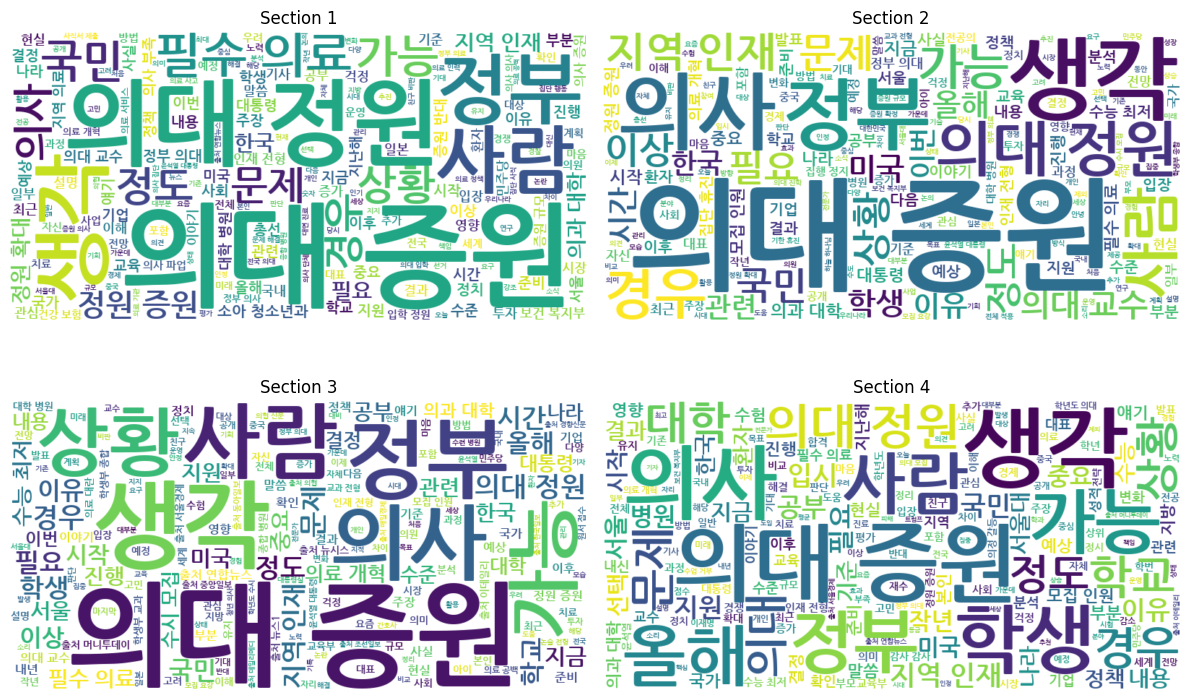

In [21]:
# 불용어 처리 전: 통합 데이터의 제목·본문·댓글 명사를 합쳐 section별 워드클라우드로 시각화합니다.
# (폰트·크기·배경색은 03 section_analysis.ipynb Step 3 WordCloud와 동일)
from wordcloud import WordCloud
import matplotlib.pyplot as plt

_nanum_ttf = PROJECT_ROOT / "nanum-gothic" / "NanumGothicBold.ttf"
OUT_WC = OUTPUTS_ANALYSIS_WORDCLOUD


def row_nouns_pre_stopword(row):
    parts = []
    for col in ("title_token_noun", "document_token_noun", "comment_token_noun"):
        parts.extend(ensure_token_list(row.get(col)))
    return parts


wc_df = combined_df.copy()
wc_df["nouns_pre_stopword"] = wc_df.apply(row_nouns_pre_stopword, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, s in enumerate((1, 2, 3, 4)):
    ax = axes.ravel()[i]
    text = " ".join(
        w for row in wc_df.loc[wc_df["section"] == s, "nouns_pre_stopword"] for w in row
    )
    wc = (
        WordCloud(font_path=str(_nanum_ttf), width=800, height=400, background_color="white").generate(text)
        if text.strip()
        else None
    )
    if wc:
        ax.imshow(wc, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "(empty)", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"Section {s}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_WC / "wordcloud_by_section_pre_stopword.png", dpi=150, bbox_inches="tight")
plt.show()


## 불용어 레이어와 고착어 후보 생성

이 단계의 목적은 01 단계에서 만든 명사 토큰을 바로 분석에 쓰지 않고, 불용어 제거 과정을 컬럼으로 나누어 추적 가능하게 만드는 것입니다.

컬럼 흐름은 다음과 같습니다.

- `*_raw`: 01 전처리에서 만든 원본 명사 토큰을 백업한 컬럼입니다. 이후 불용어 처리를 하더라도 원본 토큰을 다시 확인할 수 있습니다.
- `*_clean`: `stopwords_common.txt`와 `stopwords-ko.txt`를 적용한 결과입니다. 모든 section에 공통으로 제거할 단어를 먼저 뺍니다.
- `corpus_clean`: 제목·본문·댓글의 `*_clean` 토큰을 한 문서 단위 문자열로 합친 값입니다. 고착어/고유어 후보를 계산하는 TF-IDF 입력으로 사용합니다.
- 고착어 후보 CSV: 자동으로 제거되는 단어 목록이 아니라, section별 로컬 불용어 파일을 사람이 점검하기 위한 후보 자료입니다.

즉, 이 셀은 공통 불용어를 먼저 적용하고, 그 결과를 바탕으로 `outputs/analysis/tfidf/`에 고착어·고유어 후보 CSV를 저장합니다. 실제 최종 제거는 다음 셀에서 `stopwords_local_section*.txt`를 읽어 `*_final` 컬럼을 만들 때 이루어집니다.

#### sticky_score 로직(고착어 계산) 수학적 해석 
이 로직은 자주 나오는데(doc_freq↑), 시기별 특징은 없는(max_tfidf↓) 단어를 찾아내기 위해 설계되었습니다.

- 분자 (doc_freq): 이 단어가 얼마나 많은 문서에 골고루 퍼져 있는가? (보편성)
- 분모 (1.0 + max_tfidf * 1000): 이 단어가 특정 섹션에서 유독 튀는 성질(특이성)이 있는가?
- 해석: max_tfidf가 낮을수록(즉, 섹션별 변별력이 없을수록) 분모가 작아져 전체적인 sticky_score가 치솟습니다. 즉, 사태의 본질과는 상관없이 습관적으로 쓰이는 배경 소음 같은 단어를 검거하는 공식

In [ ]:
# 원본 명사 보존, 공통 불용어 적용, 고착어 후보 산출을 순서대로 수행합니다.
df = combined_df.copy()

TOKEN_COLS = ["title_token_noun", "document_token_noun", "comment_token_noun"]
SECTION_IDS = (1, 2, 3, 4)

# CSV/PKL 입력 과정에서 문자열이나 NaN이 섞일 수 있으므로 토큰 컬럼을 list[str]로 통일합니다.
for col in TOKEN_COLS:
    df[col] = df[col].map(ensure_token_list)

# *_raw 컬럼은 불용어 처리 전 원본 명사 리스트입니다.
# title_token_noun_raw, document_token_noun_raw, comment_token_noun_raw
snapshot_noun_columns(df)

# 댓글 목록과 댓글 수는 이후 반응 지표 분석에서도 쓰기 때문에 안전한 형식으로 보조 컬럼을 만듭니다.
df["comment_list_parsed"] = df["comment_list"].map(parse_comment_list_cell)
df["comment_cnt_int"] = df["comment_cnt"].map(safe_int_comment_cnt)

# 공통 불용어는 모든 section에 동일하게 적용합니다.
# stopwords_common.txt: 프로젝트 주제상 제거할 단어
# stopwords-ko.txt: 일반 한국어 불용어
global_sw = load_stopword_files(STOP_COMMON, STOP_KO)
print("공통 불용어 수:", len(global_sw))

# *_raw에서 공통 불용어를 제거해 *_clean 컬럼을 만듭니다.
# 이 단계에서는 section별 로컬 불용어는 아직 적용하지 않습니다.
apply_global_clean(df, global_sw, src_suffix="_raw", dst_suffix="_clean")

# TF-IDF는 문서별 문자열을 입력으로 받으므로 제목·본문·댓글 clean 토큰을 하나로 합칩니다.
df["corpus_clean"] = df.apply(lambda row: row_merged_tokens(row, suffix="_clean"), axis=1)
texts = df["corpus_clean"].fillna("").astype(str).tolist()
sections = df["section"].astype(int).to_numpy()

# section별 평균 TF-IDF를 같은 단어 공간에서 계산합니다.
# 이 결과는 고유어 후보와 고착어 후보를 판단하는 기준표입니다.
wide_tfidf, _, _ = section_mean_tfidf_matrix(texts, sections, section_ids=SECTION_IDS, min_df=2, max_df=0.98)
wide_tfidf.to_csv(OUTPUTS_ANALYSIS_TFIDF / "tfidf_section_mean_wide.csv", encoding="utf-8-sig")

# 고유어 후보: 특정 section의 평균 TF-IDF가 다른 section보다 높은 단어입니다.
# 발표 분석용 최종 결과가 아니라, section별 특징어를 점검하기 위한 후보 CSV입니다.
unique_scores = unique_keyword_scores(wide_tfidf, section_ids=SECTION_IDS)
for section_id in SECTION_IDS:
    col = f"diff_vs_others_max_s{section_id}"
    unique_scores.sort_values(col, ascending=False).head(200).to_csv(
        OUTPUTS_ANALYSIS_TFIDF / f"unique_keyword_candidates_section{section_id}.csv",
        encoding="utf-8-sig",
    )

# 고착어 후보: 많은 문서에 반복 등장하지만 section을 구분하는 힘은 약한 단어입니다.
# 이런 단어는 분석 노이즈일 가능성이 있어 로컬 불용어 후보로 점검합니다.
df_counts = document_frequency_from_texts(texts)
sticky = pd.DataFrame(
    {
        "doc_freq": df_counts.reindex(wide_tfidf.index).fillna(0).astype(int),
        "max_section_mean_tfidf": wide_tfidf.max(axis=1),
        "mean_section_mean_tfidf": wide_tfidf.mean(axis=1),
    }
)

# 문서 빈도가 높고 TF-IDF 변별력이 낮을수록 sticky_score가 커집니다.
sticky["sticky_score"] = sticky["doc_freq"] / (1.0 + sticky["max_section_mean_tfidf"] * 1000)
sticky.sort_values("sticky_score", ascending=False).head(200).to_csv(
    OUTPUTS_ANALYSIS_TFIDF / "sticky_keyword_candidates.csv",
    encoding="utf-8-sig",
)

# 전체 기준 고착어와 별도로 section 내부에서 반복되는 고착어 후보도 저장합니다.
sticky_by_section = sticky_candidates_per_section(texts, sections, section_ids=SECTION_IDS, min_df=2, max_df=0.98, top_n=200)
for section_id, table in sticky_by_section.items():
    if not table.empty:
        table.to_csv(
            OUTPUTS_ANALYSIS_TFIDF / f"sticky_keyword_candidates_section{section_id}.csv",
            encoding="utf-8-sig",
        )

print("고착어 후보 CSV 저장 폴더:", OUTPUTS_ANALYSIS_TFIDF)
sticky.sort_values("sticky_score", ascending=False).head(10)

공통 불용어 수: 789
고착어 후보 CSV 저장 폴더: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/outputs/analysis/tfidf


,title,doc,like,comment_cnt,comment_list,ch,date,section,title_token_noun,document_token_noun,comment_token_noun,title_token_noun_raw,document_token_noun_raw,comment_token_noun_raw,comment_list_parsed,comment_cnt_int,title_token_noun_clean,document_token_noun_clean,comment_token_noun_clean,corpus_clean
0,지혜로운 자는 명문대 학벌추구 하지마라 11 의약대 정원 증원하라,아우터레위 블로거 입니다 사실 이 거 오래 전에도 쓴 것입니다 수년 전에 쓴 내용입...,9,3,[{'comment_content': '바울을 치료하며 선교를 하러 간 루카와 같은...,blog,2024-01-01,1,"[지혜, 명문대, 학벌, 추구, 약대, 정원, 증원]","[아우터레위, 블로거, 수년, 내용, 숫자, 개업의, 멸망, 예언, 하나님, 본론,...","[바울, 치료, 선교, 루카, 청년, 배출, 지금, 한류, 현상, 하나님, 개입, ...","[지혜, 명문대, 학벌, 추구, 약대, 정원, 증원]","[아우터레위, 블로거, 수년, 내용, 숫자, 개업의, 멸망, 예언, 하나님, 본론,...","[바울, 치료, 선교, 루카, 청년, 배출, 지금, 한류, 현상, 하나님, 개입, ...",[{'comment_content': '바울을 치료하며 선교를 하러 간 루카와 같은...,3,"[지혜, 명문대, 학벌, 추구, 약대, 정원]","[아우터레위, 블로거, 수년, 숫자, 개업의, 멸망, 예언, 하나님, 본론, 의약,...","[바울, 치료, 선교, 루카, 청년, 배출, 지금, 한류, 현상, 하나님, 개입, ...",지혜 명문대 학벌 추구 약대 정원 아우터레위 블로거 수년 숫자 개업의 멸망 예언 하...
1,입시정보 2028 대입 개편안 미적분 현 미적분 기하 수능 제외 대학별 고사 증가 ...,새로운 한 해가 시작되었습니다 다들 새해 복 많이 받으시길 기원합니다 작년 한 해는...,29,14,[{'comment_content': '항상 좋은정보 올려주셔서 감사합니다 새해에는...,blog,2024-01-01,1,"[입시, 정보, 대입, 개편안, 미적분, 미적분, 기하, 수능, 제외, 대학, 고사...","[시작, 새해, 기원, 작년, 개인, 올해, 오늘, 대입, 개편안, 중요, 부분, ...","[정보, 감사, 새해, 감사, 새해, 행복, 새해, 건강, 행복, 감사, 행복, 새...","[입시, 정보, 대입, 개편안, 미적분, 미적분, 기하, 수능, 제외, 대학, 고사...","[시작, 새해, 기원, 작년, 개인, 올해, 오늘, 대입, 개편안, 중요, 부분, ...","[정보, 감사, 새해, 감사, 새해, 행복, 새해, 건강, 행복, 감사, 행복, 새...",[{'comment_content': '항상 좋은정보 올려주셔서 감사합니다 새해에는...,14,"[입시, 대입, 개편안, 미적분, 미적분, 기하, 수능, 대학, 고사, 증가, 조선일보]","[새해, 기원, 개인, 대입, 개편안, 미적분, 미적분, 기하, 수능, 대학, 입장...","[감사, 새해, 감사, 새해, 행복, 새해, 건강, 행복, 감사, 행복, 새해, 정...",입시 대입 개편안 미적분 미적분 기하 수능 대학 고사 증가 조선일보 새해 기원 개인...
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,일단 요근래 나온 자산의 개념정리에 대해서 생각을 해 보겟습니다 일단 우리나라에서 ...,14,4,"[{'comment_content': '감사합니다', 'comment_like': ...",blog,2024-01-01,1,"[이때, 뉴스, 생각, 정리, 자산, 자산가, 미술품, 투자, 수단, 추세, 직업,...","[근래, 자산, 개념, 정리, 생각, 우리나라, 자산, 이상, 가구, 우리나라, 가...","[감사, 정성, 포스팅, 서이추, 가용, 소통]","[이때, 뉴스, 생각, 정리, 자산, 자산가, 미술품, 투자, 수단, 추세, 직업,...","[근래, 자산, 개념, 정리, 생각, 우리나라, 자산, 이상, 가구, 우리나라, 가...","[감사, 정성, 포스팅, 서이추, 가용, 소통]","[{'comment_content': '감사합니다', 'comment_like': ...",4,"[뉴스, 정리, 자산, 자산가, 미술품, 투자, 수단, 추세, 직업, 향후, 평준,...","[근래, 자산, 개념, 정리, 우리나라, 자산, 가구, 우리나라, 가구, 평균, 자...","[감사, 정성, 포스팅, 서이추, 가용, 소통]",뉴스 정리 자산 자산가 미술품 투자 수단 추세 직업 향후 평준 자식 주식 근래 자산...
3,의료계 충격 보건복지부 차관의 망언에 대한 전국광역시도의사회장협의회의 강력한 반발,의료계 충격 보건복지부 차관의 망언에 대한 전국광역시도의사회장협의회의 강력한 반발 ...,28,1,[{'comment_content': '안녕하세요 행복한 영상이 있어 공유하고자 올...,blog,2024-01-01,1,"[의료, 충격, 보건, 복지, 차관, 망언, 전국, 광역, 시도, 의사, 회장, 협...","[의료, 충격, 보건, 복지, 차관, 망언, 전국, 광역, 시도, 의사, 회장, 협...","[안녕, 행복, 영상, 공유]","[의료, 충격, 보건, 복지, 차관, 망언, 전국, 광역, 시도, 의사, 회장, 협...","[의료, 충격, 보건, 복지, 차관, 망언, 전국, 광역, 시도, 의사, 회장, 협...","[안녕, 행복, 영상, 공유]",[{'comment_content': '안녕하세요 행복한 영상이 있어 공유하고자 올...,1,"[충격, 보건, 복지, 차관, 망언, 전국, 광역, 회장, 협의회, 반발]","[충격, 보건, 복지, 차관, 망언, 전국, 광역, 회장, 협의회, 반발, 스카이플...","[행복, 영상, 공유]",충격 보건 복지 차관 망언 전국 광역 회장 협의회 반발 충격 보건 복지 차관 망언 ...
4,의대 증원 관련 기사입니다,단독 이과 수험생 62 교차지원 고려 의대증원 노린 반수 늘 듯 동아일보 단독 이과...,0,4,"[{'comment_content': '점점 의대중심의 세상이 되어가네요', 'co...",cafe,2024-01-01,1,"[의대, 증원, 관련, 기사]","[단독, 이과, 수험, 교차, 지원, 고려, 의대, 증원, 반수, 동아일보, 단독,...","[의대, 중심, 세상, 나중, 의대, 취급, 다양, 직업, 존재, 의대, 의대, 열...","[의대, 증원, 관련, 기사]","[단독, 이과, 수험, 교차, 지원, 고려, 의대, 증원, 반수, 동아일보, 단독,...","[의대, 중심, 세상, 나중, 의대, 취급, 다양, 직업, 존재, 의대, 의대, 열...","[{'comment_content': '점점 의대중심의 세상이 되어가네요', 'co...",4,[],"[이과, 수험, 교차, 지원, 고려, 반수, 동아일보, 이과, 수험, 교차, 지원,...","[중심, 세상, 나중, 취급, 직업, 존재, 열풍, 장난]",이과 수험 교차 지원 고려 반수 동아일보 이과 수험 교차 지원 고려 반수 지난해 대...


### 불용어와 고착어 후보 결과 해석

공통 불용어 789개가 적용되었고, 그 결과를 기준으로 전체 고착어 후보와 section별 고착어 후보가 저장되었습니다. 여기서 고착어 후보는 즉시 삭제되는 단어가 아니라, 문서 전반에 반복되지만 section 구분에는 약한 단어를 찾아 불용어 사전을 점검하기 위한 근거입니다. 이 과정을 통해 `전체`, `최근`, `확인`처럼 배경 소음에 가까운 단어의 영향을 줄입니다.

## 로컬 불용어 적용과 layered PKL 저장

앞 셀에서 만든 고착어 후보 CSV를 확인한 뒤, 실제로 제거해야 한다고 판단한 단어는 `stopwords/stopwords_local_section1.txt`부터 `stopwords_local_section4.txt`까지의 파일에 직접 추가합니다.

이 셀은 현재 로컬 불용어 파일을 읽어 section별로 다른 단어를 제거합니다.

- 입력 컬럼: 공통 불용어까지 제거된 `*_clean`
- 적용 기준: 각 행의 `section` 값에 맞는 `stopwords_local_section*.txt`
- 출력 컬럼: 최종 분석에 사용할 `*_final`, `nouns_final`, `corpus_final`

`nouns_final`은 03 분석 노트북의 워드클라우드·TF-IDF·KMeans·LDA가 공통으로 사용하는 최종 토큰 리스트입니다.

로컬 불용어는 분석을 용이하게 진행하기 위해 고착어를 계산한 명사만 추가합니다. 직접 추가는 공통 불용어에 추가해 분석의 결과를 해치지 않습니다.

In [6]:
# section별 로컬 불용어를 적용해 최종 분석용 토큰을 확정합니다.
# apply_local_clean은 각 행의 section 값을 보고 stopwords_local_section*.txt를 자동 선택합니다.
apply_local_clean(df, STOPWORDS_DIR, src_suffix="_clean", dst_suffix="_final")

# corpus_final은 최종 토큰을 공백으로 이어 붙인 문자열입니다.
# 03 단계의 TF-IDF/KMeans/LDA처럼 문자열 입력이 필요한 분석에서 사용합니다.
df["corpus_final"] = df.apply(lambda row: row_merged_tokens(row, suffix="_final"), axis=1)

# layered PKL에는 raw/clean/final 컬럼이 모두 들어갑니다.
# 따라서 03 분석 단계에서 불용어 처리를 다시 하지 않아도 됩니다.
df.to_pickle(LAYERED_PKL_OUT)

print("layered PKL 저장:", LAYERED_PKL_OUT)
print("최종 토큰 수 요약:")
print(df["nouns_final"].map(len).describe())
df[["title", "section", "ch", "nouns_final", "corpus_final"]].head()

layered PKL 저장: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/integrated/crolling_total_estate_press_layered.pkl
최종 토큰 수 요약:
count     9080.000000
mean       360.876542
std        815.280452
min          1.000000
25%        100.750000
50%        192.000000
75%        345.000000
max      27299.000000
Name: nouns_final, dtype: float64


,title,section,ch,nouns_final,corpus_final
0,지혜로운 자는 명문대 학벌추구 하지마라 11 의약대 정원 증원하라,1,blog,"[지혜, 명문대, 학벌, 추구, 약대, 정원, 아우터레위, 블로거, 수년, 숫자, ...",지혜 명문대 학벌 추구 약대 정원 아우터레위 블로거 수년 숫자 개업의 멸망 예언 하...
1,입시정보 2028 대입 개편안 미적분 현 미적분 기하 수능 제외 대학별 고사 증가 ...,1,blog,"[입시, 대입, 개편안, 미적분, 미적분, 기하, 수능, 대학, 고사, 증가, 조선...",입시 대입 개편안 미적분 미적분 기하 수능 대학 고사 증가 조선일보 새해 기원 대입...
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,1,blog,"[뉴스, 정리, 자산, 자산가, 미술품, 투자, 수단, 추세, 직업, 향후, 평준,...",뉴스 정리 자산 자산가 미술품 투자 수단 추세 직업 향후 평준 자식 주식 근래 자산...
3,의료계 충격 보건복지부 차관의 망언에 대한 전국광역시도의사회장협의회의 강력한 반발,1,blog,"[충격, 보건, 복지, 차관, 망언, 광역, 회장, 협의회, 반발, 충격, 보건, ...",충격 보건 복지 차관 망언 광역 회장 협의회 반발 충격 보건 복지 차관 망언 광역 ...
4,의대 증원 관련 기사입니다,1,cafe,"[이과, 수험, 교차, 지원, 반수, 동아일보, 이과, 수험, 교차, 지원, 반수,...",이과 수험 교차 지원 반수 동아일보 이과 수험 교차 지원 반수 지난해 대학 수학 능...


## 최종 통합 저장물 검증

`layered.pkl`을 다시 읽어 최종 분석 입력에 필요한 컬럼이 모두 있는지 확인합니다. 또한 채널과 section의 교차표, 최종 토큰 길이, 빈 토큰 문서 수를 확인해 03 분석으로 넘어갈 수 있는 상태인지 점검합니다.

In [7]:
# 최종 layered PKL을 재로드해 03 분석 입력 무결성을 확인합니다.
validated_layered = pd.read_pickle(LAYERED_PKL_OUT)
required_cols = ["section", "ch", "nouns_final", "corpus_final", "title_token_noun_final", "document_token_noun_final", "comment_token_noun_final"]
missing_cols = [col for col in required_cols if col not in validated_layered.columns]
if missing_cols:
    raise KeyError(f"통합 layered PKL 누락 컬럼: {missing_cols}")

print("검증 파일:", LAYERED_PKL_OUT)
print("저장물 행 수:", len(validated_layered))
print("채널 x section 분포:")
print(pd.crosstab(validated_layered["ch"], validated_layered["section"]))
print("최종 토큰 수 요약:")
print(validated_layered["nouns_final"].map(len).describe())
print("빈 최종 토큰 문서 수:", int((validated_layered["nouns_final"].map(len) == 0).sum()))
validated_layered[["title", "section", "ch", "nouns_final"]].head(3)

검증 파일: /Users/hyerimchoi/DJD/datacrolling/20241983최혜림_20241285이서연_드론영상비정형데이터AI분석_중간과제/20241983최혜림_20241285이서연_드론비정형데이터AI분석/data/integrated/crolling_total_estate_press_layered.pkl
저장물 행 수: 9080
채널 x section 분포:
section     1     2     3     4
ch                             
blog     1664  1789  1685   216
cafe      671   650  1376  1029
최종 토큰 수 요약:
count     9080.000000
mean       360.876542
std        815.280452
min          1.000000
25%        100.750000
50%        192.000000
75%        345.000000
max      27299.000000
Name: nouns_final, dtype: float64
빈 최종 토큰 문서 수: 0


,title,section,ch,nouns_final
0,지혜로운 자는 명문대 학벌추구 하지마라 11 의약대 정원 증원하라,1,blog,"[지혜, 명문대, 학벌, 추구, 약대, 정원, 아우터레위, 블로거, 수년, 숫자, ..."
1,입시정보 2028 대입 개편안 미적분 현 미적분 기하 수능 제외 대학별 고사 증가 ...,1,blog,"[입시, 대입, 개편안, 미적분, 미적분, 기하, 수능, 대학, 고사, 증가, 조선..."
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,1,blog,"[뉴스, 정리, 자산, 자산가, 미술품, 투자, 수단, 추세, 직업, 향후, 평준,..."


## 02 통합 단계 결론

통합·불용어 단계에서 의대 증원 담론을 시기별로 공정하게 비교할 수 있는 기준을 만들었습니다. 블로그와 카페를 합쳐 정책 설명, 의료현장 반응, 입시 반응을 하나의 말뭉치로 놓고, 반복적·절차적 단어를 정리했기 때문에 03 분석에서는 실제 관심 이동을 더 직접적으로 볼 수 있습니다. 이 기준 위에서 초기의 `정부·정원·전공의·환자` 중심 반응과 후반의 `대학·전형·수능·입시` 중심 반응을 같은 척도로 비교합니다.
